In [42]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns

import tensorflow as tf

import keras
from keras import layers, models, losses, optimizers
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [43]:
from keras.callbacks import Callback

In [44]:
def student_model(num_classes):
    
    input_shapes = (32, 32, 100, 1)
    
    model = models.Sequential()   
         
    model.add(layers.TimeDistributed(layers.Conv2D(16, (3, 3), activation='relu'),input_shape=input_shapes))    
    model.add(layers.TimeDistributed(layers.MaxPooling2D((3, 3))))    
    
    model.add(layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu')))    
    model.add(layers.TimeDistributed(layers.MaxPooling2D((3, 3))))    
    
    model.add(layers.TimeDistributed(layers.Flatten()))        

    model.add(layers.LSTM(16))   
    model.add(layers.Dense(16, activation='relu'))       
    model.add(layers.Dense(num_classes))#, activation='softmax'

    #print("\nStudent model summary:")
    #model.summary()
    return model
    
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher, temperature=1.0, alpha=0.5):
        super(Distiller, self).__init__()
        self.student = student
        self.teacher = teacher
        self.temperature = temperature
        self.alpha = alpha
        self.student_loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)#
        self.distillation_loss_fn = losses.KLDivergence()
        self.metric = tf.keras.metrics.SparseCategoricalAccuracy(name="distiller accuracy")

    def compile(self,optimizer=optimizers.Adam()):
        super(Distiller, self).compile()
        self.optimizer = optimizer

    def train_step(self, data):
        x, y_true = data

        # 前向傳播
        teacher_pred = self.teacher(x, training=False)#即x輸入給teacher使之輸出(predict)
        with tf.GradientTape() as tape:
            student_pred = self.student(x, training=True)#即x輸入給student使之輸出(predict)

            # student 對真實 label 的 loss
            student_loss = self.student_loss_fn(y_true, student_pred)#計算student對真實label的loss
            
            
            # distillation loss (soft target)，注意加上 temperature 的處理
            teacher_soft = tf.nn.softmax(teacher_pred / self.temperature)
            student_soft = tf.nn.softmax(student_pred / self.temperature)
            distill_loss = self.distillation_loss_fn(teacher_soft, student_soft)
            """
            distill_loss = self.distillation_loss_fn(teacher_pred, student_pred)
            """
            # 總損失
            total_loss = self.alpha * student_loss + (1 - self.alpha) * distill_loss

        grads = tape.gradient(total_loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))

        self.metric.update_state(y_true, student_pred)
        return {"train step loss": total_loss, "train step accuracy": self.metric.result()}

    def test_step(self, data):
        x, y_true = data
        student_pred = self.student(x, training=False)
        loss = self.student_loss_fn(y_true, student_pred)
        self.metric.update_state(y_true, student_pred)
        return {"test step loss": loss, "test step accuracy": self.metric.result()}

def fit_model(train_data, train_labels, valid_data, valid_labels, callback, parameter_epoch):#
    
    student = student_model(3)  # 使用自定義的 student 架構

    teacher_model_path=r"D:\gesture_recognition_by_mmWave_and_AI\knowledge_distillation\teacher_model\gesture_model_RDI_data_KD_teacher.h5"#
    teacher = models.load_model(teacher_model_path)  # 載入教師模型
    teacher.trainable = False  # 凍結權重
    
    distiller = Distiller(student=student, teacher=teacher)#, temperature=6, alpha=0.3
    distiller.compile()
    distiller.fit(x=train_data, y=train_labels, validation_data=(valid_data, valid_labels), callbacks=callback, epochs=parameter_epoch, batch_size=int(train_data.shape[0]/5.0), shuffle=True)#
    return distiller


In [45]:
class EpochSaver(Callback):
    def __init__(self, save_every=10):
        super(EpochSaver, self).__init__()
        self.save_every = save_every

    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % self.save_every == 0:

            filename = r"D:\mmWave_gesture\data_and_model\model\diff_ep_KD_model\KD_model_{}.h5".format(epoch+1)
            print("\nfile name: ", filename) 
            self.model.student.save(filename)
            print(f'\nSaved: {filename}')

In [46]:
train_data_path=r"D:\gesture_recognition_by_mmWave_and_AI\knowledge_distillation\processed_data\KD_train_0.5.npz"
train_data=np.load(train_data_path)['data']
train_labels=np.load(train_data_path)['labels']

val_data_path=r"D:\gesture_recognition_by_mmWave_and_AI\processed_data\val.npz"
val_data=np.load(val_data_path)['data']
val_data_labels=np.load(val_data_path)['labels']

test_data_path=r"D:\gesture_recognition_by_mmWave_and_AI\processed_data\test.npz"
test_data=np.load(test_data_path)['data']
test_labels=np.load(test_data_path)['labels']

In [47]:
callback_list=[EpochSaver(save_every=10)]

In [57]:
ep=300

In [49]:
KD=fit_model(train_data, train_labels, val_data, val_data_labels,parameter_epoch=ep, callback=callback_list)#

Epoch 1/1000
6/6 [==============================] - 4s 343ms/step - train step loss: 0.9599 - train step accuracy: 0.2417 - val_test step loss: 1.1009 - val_test step accuracy: 0.3333
Epoch 2/1000
6/6 [==============================] - 1s 211ms/step - train step loss: 0.9472 - train step accuracy: 0.4280 - val_test step loss: 1.0403 - val_test step accuracy: 0.5556
Epoch 3/1000
6/6 [==============================] - 2s 287ms/step - train step loss: 0.8939 - train step accuracy: 0.6754 - val_test step loss: 1.1003 - val_test step accuracy: 0.5873
Epoch 4/1000
6/6 [==============================] - 2s 265ms/step - train step loss: 0.8354 - train step accuracy: 0.7678 - val_test step loss: 1.0857 - val_test step accuracy: 0.5397
Epoch 5/1000
6/6 [==============================] - 1s 216ms/step - train step loss: 0.8402 - train step accuracy: 0.7758 - val_test step loss: 1.0462 - val_test step accuracy: 0.6032
Epoch 6/1000
6/6 [==============================] - 1s 219ms/step - train step l

d:\mmWave_gesture\gesture_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - 3s 446ms/step - train step loss: 0.6645 - train step accuracy: 0.7481 - val_test step loss: 0.9903 - val_test step accuracy: 0.6190
Epoch 12/1000
6/6 [==============================] - 1s 204ms/step - train step loss: 0.5048 - train step accuracy: 0.7443 - val_test step loss: 0.8359 - val_test step accuracy: 0.6190
Epoch 13/1000
6/6 [==============================] - 1s 209ms/step - train step loss: 0.4140 - train step accuracy: 0.7690 - val_test step loss: 0.8222 - val_test step accuracy: 0.7143
Epoch 14/1000
6/6 [==============================] - 1s 232ms/step - train step loss: 0.4073 - train step accuracy: 0.8775 - val_test step loss: 0.8685 - val_test step accuracy: 0.7619
Epoch 15/1000
6/6 [==============================] - 2s 255ms/step - train step loss: 0.4553 - train step accuracy: 0.8544 - val_test step loss: 0.7897 - val_test step accuracy: 0.7619
Epoch 16/1000
6/6 [==============================] - 1s 210ms/step - train step loss: 0.3

In [58]:
epochs_record =list()

train_accuracy =list()
test_accuracy =list()

train_loss =list()
test_loss =list()

In [59]:
for epoch in range(10,ep+10,10):
    print("\nepoch : ", epoch)
    KD_model_path=r"D:\mmWave_gesture\data_and_model\model\diff_ep_KD_model\KD_model_{}.h5".format(epoch)
    
    KD_model=models.load_model(KD_model_path)  # 載入教師模型
    
    KD_model.compile(optimizer=optimizers.Adam(),loss=losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    
    loss_train, acc_train = KD_model.evaluate(train_data, train_labels)
    loss_test, acc_test = KD_model.evaluate(test_data, test_labels)
    
    epochs_record.append(epoch)
    
    train_accuracy.append(acc_train*100)
    test_accuracy.append(acc_test*100)
    
    train_loss.append(loss_train)
    test_loss.append(loss_test)



epoch :  10
3/3 [==============================] - 0s 95ms/step - loss: 0.7628 - accuracy: 0.6778

epoch :  20
3/3 [==============================] - 0s 86ms/step - loss: 0.4213 - accuracy: 0.8778

epoch :  30
3/3 [==============================] - 0s 81ms/step - loss: 0.2944 - accuracy: 0.8889

epoch :  40
3/3 [==============================] - 0s 73ms/step - loss: 0.2760 - accuracy: 0.8889

epoch :  50
3/3 [==============================] - 0s 74ms/step - loss: 0.2512 - accuracy: 0.9222

epoch :  60
3/3 [==============================] - 0s 76ms/step - loss: 0.2593 - accuracy: 0.9111

epoch :  70
3/3 [==============================] - 0s 76ms/step - loss: 0.2240 - accuracy: 0.9222

epoch :  80
3/3 [==============================] - 0s 88ms/step - loss: 0.2220 - accuracy: 0.9111

epoch :  90
3/3 [==============================] - 0s 100ms/step - loss: 0.2156 - accuracy: 0.9222

epoch :  100
3/3 [==============================] - 0s 99ms/step - loss: 0.2184 - accuracy: 0.9111

epoch :

In [60]:
df = pd.DataFrame({
    'Epoch': epochs_record,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'Train Loss': train_loss,
    'Test Loss': test_loss
})

Acc

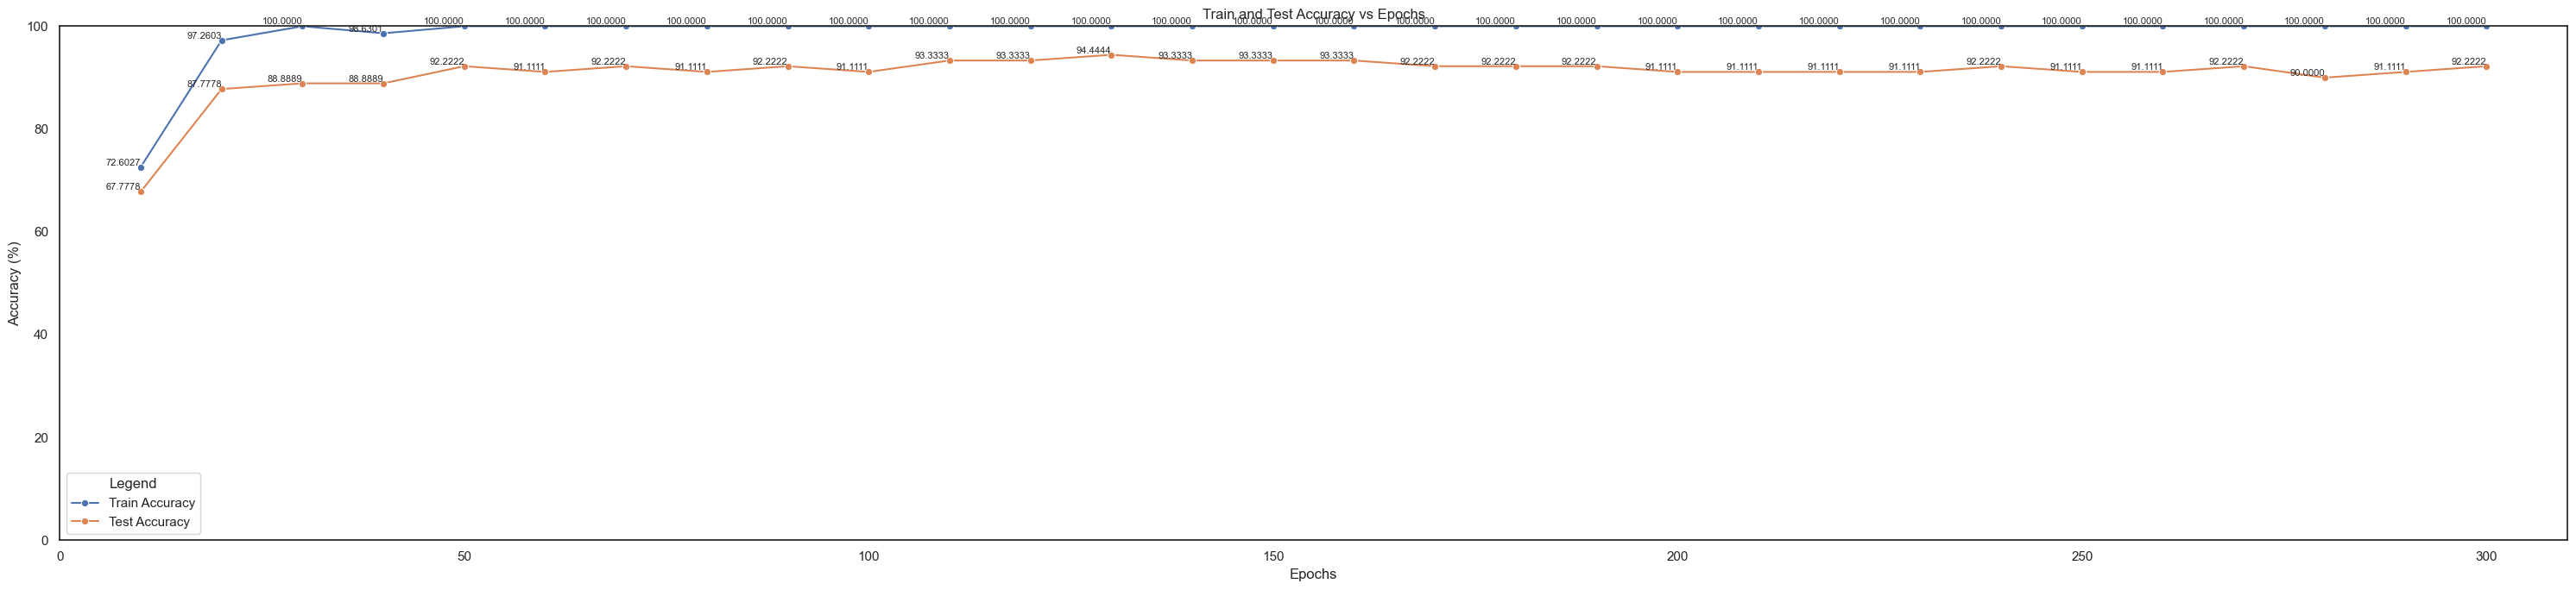

In [61]:
# 設定 Seaborn 樣式
sns.set(style='white')  # 白色背景、無格線

# ---------- 圖1：Accuracy ----------
plt.figure(figsize=(30, 7))
sns.lineplot(x='Epoch', y='value', hue='variable',
             data=pd.melt(df, ['Epoch'], value_vars=['Train Accuracy', 'Test Accuracy']),
             marker='o')

for x, y in zip(epochs_record, train_accuracy):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
for x, y in zip(epochs_record, test_accuracy):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
    
plt.title('Train and Test Accuracy vs Epochs')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xlabel('Epochs')
plt.xlim(0, ep+10)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()


Loss

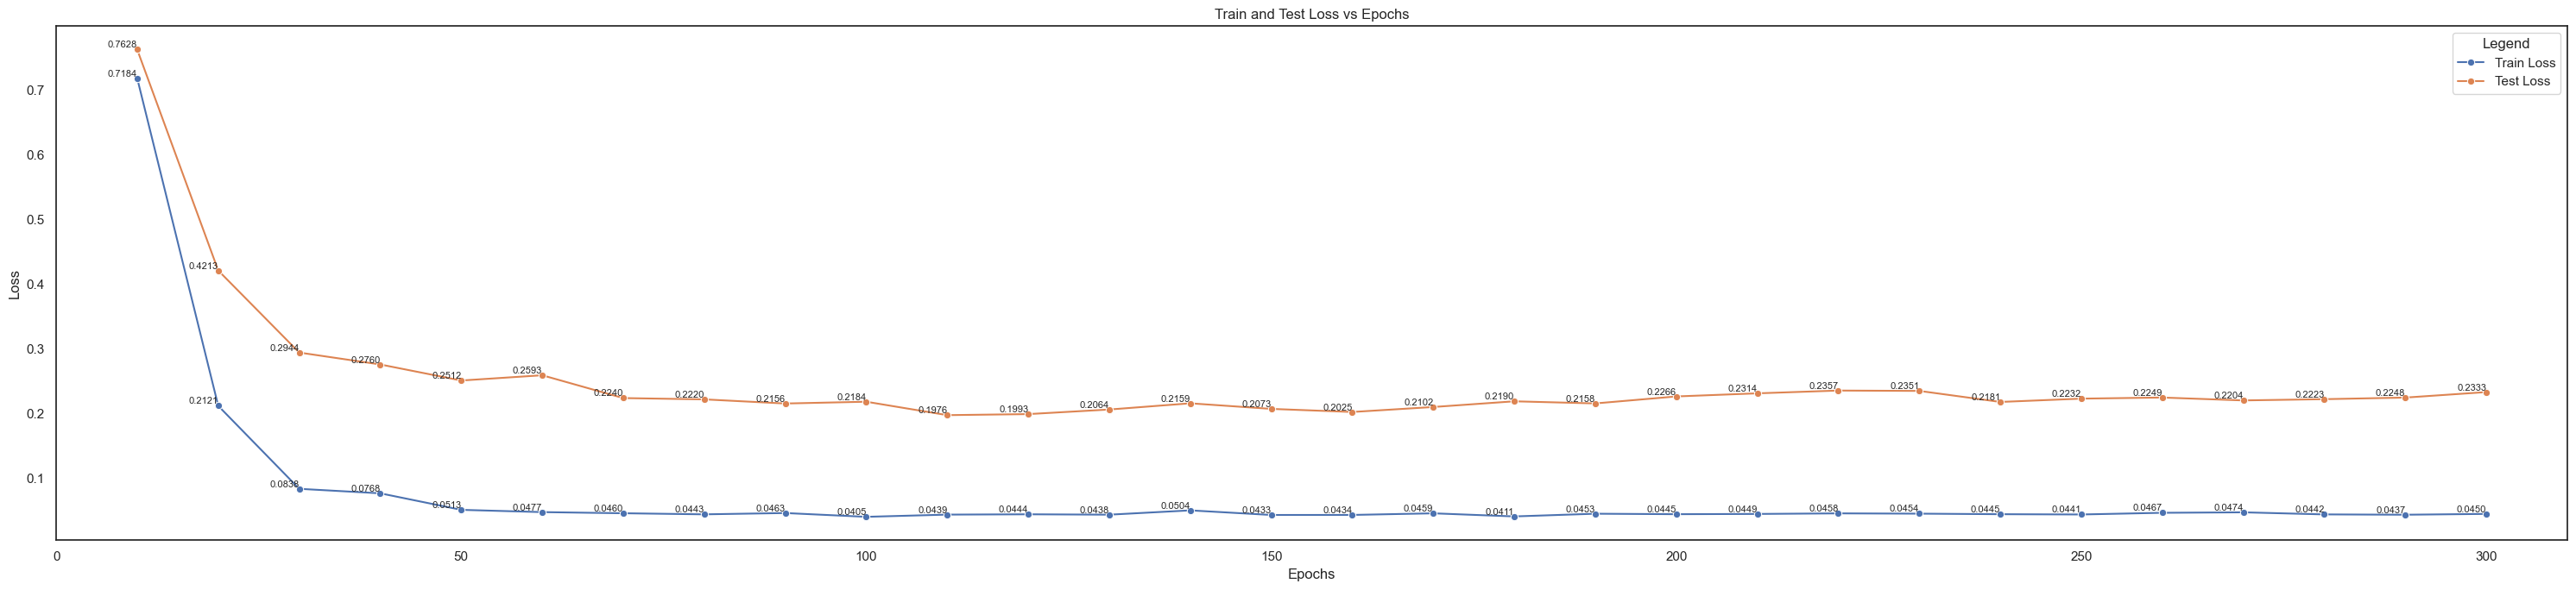

In [62]:
plt.figure(figsize=(30, 7))
sns.lineplot(x='Epoch', y='value', hue='variable',
             data=pd.melt(df, ['Epoch'], value_vars=['Train Loss', 'Test Loss']),
             marker='o')

for x, y in zip(epochs_record, train_loss):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
for x, y in zip(epochs_record, test_loss):
    plt.text(x, y, f'{y:.4f}', ha='right', va='bottom', fontsize=8)
plt.title('Train and Test Loss vs Epochs')
plt.ylabel('Loss')
#plt.ylim(0, 1)  # 可依你的實際 loss 調整
plt.xlabel('Epochs')
plt.xlim(0, ep+10)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()

In [63]:
m_path=r"D:\mmWave_gesture\data_and_model\model\diff_ep_KD_model\KD_model_100.h5"
m=models.load_model(m_path)  # 載入教師模型
m.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_10 (TimeD  (None, 32, 30, 98, 16)    160       
 istributed)                                                     
                                                                 
 time_distributed_11 (TimeD  (None, 32, 10, 32, 16)    0         
 istributed)                                                     
                                                                 
 time_distributed_12 (TimeD  (None, 32, 8, 30, 32)     4640      
 istributed)                                                     
                                                                 
 time_distributed_13 (TimeD  (None, 32, 2, 10, 32)     0         
 istributed)                                                     
                                                                 
 time_distributed_14 (TimeD  (None, 32, 640)          